<a href="https://colab.research.google.com/github/shrikant-1709044/blood_cell_classification_1.0/blob/main/experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shree Ganeshay namh

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os


In [ ]:
print("version : ", tf.__version__)

version :  2.20.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -o -q /content/drive/MyDrive/Datazip.zip -d /content/dataset/

In [ ]:
!ls /content/dataset/

Data


In [ ]:
# Load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/Data/train',
    image_size=(224, 224),
    batch_size=16,
    label_mode='categorical'
)

train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)


val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/Data/val',
    image_size=(224, 224),
    batch_size=16,
    label_mode='categorical'
)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

Found 9957 files belonging to 4 classes.
Found 2487 files belonging to 4 classes.


In [ ]:
## Model Architechure
model = keras.Sequential([

    layers.Input(shape=(224,224,3)),

    layers.Rescaling(1./255),

    ## convolution layer 1
    layers.Conv2D(filters=16, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPool2D(pool_size=2),

    ## convolution layer 2
    layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPool2D(pool_size=2),

    ## convolution layer 3
    layers.Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPool2D(pool_size=2),


    ## flattening the layers
    layers.Flatten(),

    ## fully connected layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(4, activation='softmax'),







])



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau


In [ ]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,455,204 (24.62 MB)

 Trainable params: 6,454,980 (24.62 MB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
## training model

model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=[early_stopping,lr_scheduler])


Epoch 1/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.2557 - loss: 1.6518 - val_accuracy: 0.2549 - val_loss: 1.3857 - learning_rate: 0.0010
Epoch 2/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.2414 - loss: 1.3869 - val_accuracy: 0.2505 - val_loss: 1.3864 - learning_rate: 0.0010
Epoch 3/20
621/623 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2357 - loss: 1.3868
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
623/623 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.2430 - loss: 1.3865 - val_accuracy: 0.2505 - val_loss: 1.3864 - learning_rate: 0.0010
Epoch 4/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.2456 - loss: 1.3864 - val_accuracy: 0.2505 - val_loss: 1.3863 - learning_rate: 5.0000e-04


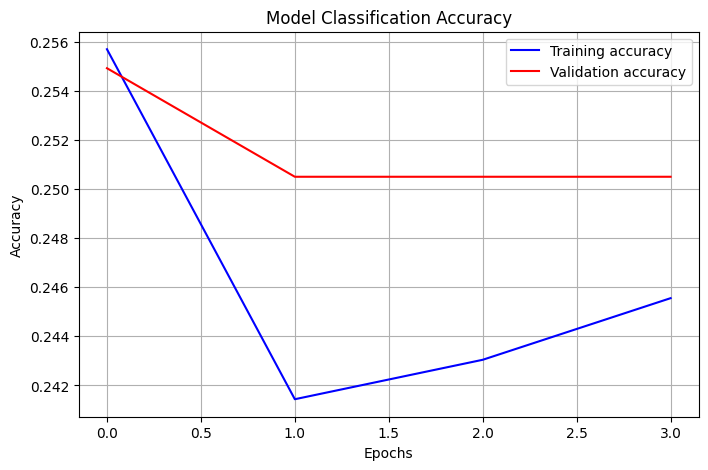

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label = 'Training accuracy', color = 'blue')
plt.plot(history.history['val_accuracy'], label = 'Validation accuracy', color = 'red')
plt.title('Model Classification Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

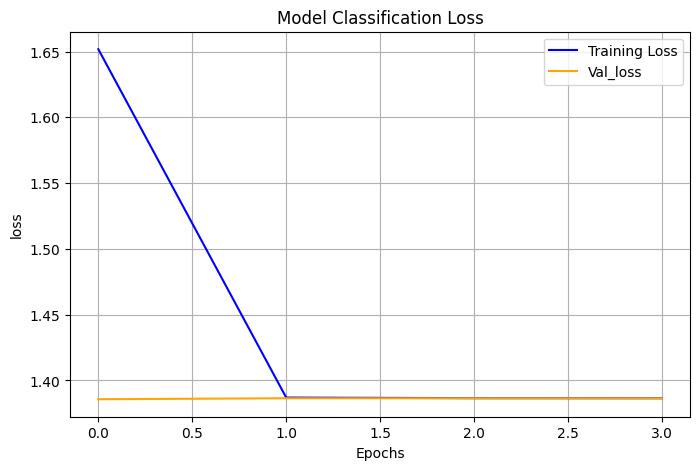

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val_loss', color='orange')
plt.title('Model Classification Loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()

156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2549 - loss: 1.3857

Overall Validation Accuracy: 25.49%
Overall Validation Loss: 1.3857

--- Detailed Classification Report ---
              precision    recall  f1-score   support

  EOSINOPHIL       0.25      0.98      0.40       623
  LYMPHOCYTE       0.43      0.00      0.01       620
    MONOCYTE       0.33      0.03      0.06       620
  NEUTROPHIL       0.00      0.00      0.00       624

    accuracy                           0.25      2487
   macro avg       0.25      0.25      0.12      2487
weighted avg       0.25      0.25      0.12      2487



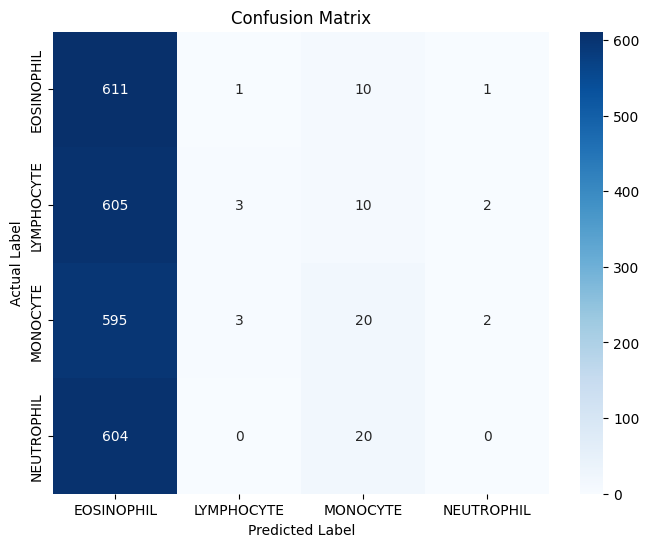

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Evaluate the model directly on the validation dataset
loss, accuracy = model.evaluate(val_ds)
print(f"\nOverall Validation Accuracy: {accuracy * 100:.2f}%")
print(f"Overall Validation Loss: {loss:.4f}")

# 2. Extract true labels and predictions for detailed analytics
true_labels = []
predicted_labels = []

# Loop through the validation dataset batches
for images, labels in val_ds:
    # Handle one-hot encoded labels vs integer labels safely
    if len(labels.shape) > 1:
        true_labels.extend(np.argmax(labels.numpy(), axis=1))
    else:
        true_labels.extend(labels.numpy())

    preds = model.predict(images, verbose=0)
    predicted_labels.extend(np.argmax(preds, axis=1))

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Retrieve class names from the directory structure
data_dir = '/content/dataset/Data/val'
class_names = sorted([name for name in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, name))])

# 3. Print out a Per-Class Precision and Recall Report
print("\n--- Detailed Classification Report ---")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

# 4. Plot a Confusion Matrix (Shows exactly what gets misclassified)
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()